In [8]:
# ============================================================
# EXPERIMENT 6 - UCI HAR DATASET
# COMPLETE DATASET DOWNLOAD + EXTRACTION + LOADING
# RUN THIS CELL ONLY
# ============================================================

import os
import shutil
import zipfile
import urllib.request
import numpy as np

# ============================================================
# 1. PATHS
# ============================================================

BASE_PATH = "/content/UCI_HAR"
OUTER_ZIP = "/content/UCI_HAR_outer.zip"

# ============================================================
# 2. REMOVE OLD BROKEN DATASET
# ============================================================

if os.path.exists(BASE_PATH):
    shutil.rmtree(BASE_PATH)

if os.path.exists(OUTER_ZIP):
    os.remove(OUTER_ZIP)

os.makedirs(BASE_PATH, exist_ok=True)

print("Old files cleared.")


# ============================================================
# 3. DOWNLOAD UCI HAR DATASET
# ============================================================

url = (
    "https://archive.ics.uci.edu/"
    "static/public/240/"
    "human+activity+recognition+using+smartphones.zip"
)

print("Downloading UCI HAR dataset...")

urllib.request.urlretrieve(
    url,
    OUTER_ZIP
)

print("Download complete.")


# ============================================================
# 4. EXTRACT OUTER ZIP
# ============================================================

print("Extracting outer ZIP...")

with zipfile.ZipFile(
    OUTER_ZIP,
    "r"
) as z:

    z.extractall(
        BASE_PATH
    )

print("Outer extraction complete.")


# ============================================================
# 5. FIND INNER "UCI HAR Dataset.zip"
# ============================================================

inner_zip = None

for root, dirs, files in os.walk(BASE_PATH):

    for file in files:

        if file == "UCI HAR Dataset.zip":

            inner_zip = os.path.join(
                root,
                file
            )

            break

    if inner_zip is not None:
        break


if inner_zip is None:

    raise FileNotFoundError(
        "Could not find the inner UCI HAR Dataset.zip"
    )


print(
    "Inner ZIP found:"
)

print(
    inner_zip
)


# ============================================================
# 6. EXTRACT INNER ZIP
# ============================================================

INNER_EXTRACT = "/content/UCI_HAR/actual_dataset"

os.makedirs(
    INNER_EXTRACT,
    exist_ok=True
)

print(
    "Extracting inner dataset..."
)

with zipfile.ZipFile(
    inner_zip,
    "r"
) as z:

    z.extractall(
        INNER_EXTRACT
    )

print(
    "Inner extraction complete."
)


# ============================================================
# 7. FIND THE REAL DATASET
#    We search for body_acc_x_train.txt
#    and IGNORE __MACOSX
# ============================================================

target_file = "body_acc_x_train.txt"

real_file = None

for root, dirs, files in os.walk(
    INNER_EXTRACT
):

    # Ignore Mac metadata
    if "__MACOSX" in root:
        continue

    if target_file in files:

        real_file = os.path.join(
            root,
            target_file
        )

        break


if real_file is None:

    raise FileNotFoundError(
        "Could not find body_acc_x_train.txt"
    )


# ============================================================
# 8. FIND DATASET ROOT
# ============================================================

# real_file looks like:
#
# .../UCI HAR Dataset/train/Inertial Signals/body_acc_x_train.txt
#
# Therefore go up 3 directories.

dataset_path = os.path.dirname(
    os.path.dirname(
        os.path.dirname(
            real_file
        )
    )
)


print("\n========================================")
print("REAL DATASET FOUND")
print("========================================")

print(
    dataset_path
)


# ============================================================
# 9. CHECK REQUIRED FOLDERS
# ============================================================

train_folder = os.path.join(
    dataset_path,
    "train"
)

test_folder = os.path.join(
    dataset_path,
    "test"
)

inertial_train = os.path.join(
    train_folder,
    "Inertial Signals"
)

inertial_test = os.path.join(
    test_folder,
    "Inertial Signals"
)


if not os.path.exists(
    inertial_train
):

    raise FileNotFoundError(
        "Training Inertial Signals folder not found."
    )


if not os.path.exists(
    inertial_test
):

    raise FileNotFoundError(
        "Testing Inertial Signals folder not found."
    )


# ============================================================
# 10. DEFINE 9 RAW SENSOR CHANNELS
# ============================================================

signals = [

    "body_acc_x",
    "body_acc_y",
    "body_acc_z",

    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",

    "total_acc_x",
    "total_acc_y",
    "total_acc_z"
]


# ============================================================
# 11. LOAD TRAINING DATA
# ============================================================

print("\nLoading training signals...")

X_train_list = []

for signal in signals:

    file_path = os.path.join(

        inertial_train,

        signal + "_train.txt"
    )

    print(
        "  Loading:",
        signal
    )

    data = np.loadtxt(
        file_path
    )

    X_train_list.append(
        data
    )


# ============================================================
# 12. STACK TRAINING DATA
# ============================================================

# Each signal:
#     (7352, 128)
#
# After stacking:
#     (7352, 128, 9)

X = np.stack(

    X_train_list,

    axis=2
)


# ============================================================
# 13. LOAD TRAINING LABELS
# ============================================================

y = np.loadtxt(

    os.path.join(

        train_folder,

        "y_train.txt"
    )

).astype(int) - 1


# ============================================================
# 14. LOAD TESTING DATA
# ============================================================

print("\nLoading testing signals...")

X_test_list = []

for signal in signals:

    file_path = os.path.join(

        inertial_test,

        signal + "_test.txt"
    )

    print(
        "  Loading:",
        signal
    )

    data = np.loadtxt(
        file_path
    )

    X_test_list.append(
        data
    )


# ============================================================
# 15. STACK TEST DATA
# ============================================================

X_test = np.stack(

    X_test_list,

    axis=2
)


# ============================================================
# 16. LOAD TEST LABELS
# ============================================================

y_test = np.loadtxt(

    os.path.join(

        test_folder,

        "y_test.txt"
    )

).astype(int) - 1


# ============================================================
# 17. CLASS NAMES
# ============================================================

class_names = [

    "WALKING",

    "WALKING_UPSTAIRS",

    "WALKING_DOWNSTAIRS",

    "SITTING",

    "STANDING",

    "LAYING"
]


# ============================================================
# 18. FINAL DATASET INFORMATION
# ============================================================

print("\n")
print("=" * 60)
print("          UCI HAR DATASET LOADED SUCCESSFULLY")
print("=" * 60)

print(
    "\nTraining X shape:",
    X.shape
)

print(
    "Training y shape:",
    y.shape
)

print(
    "Test X shape:",
    X_test.shape
)

print(
    "Test y shape:",
    y_test.shape
)

print(
    "\nSequence length:",
    X.shape[1]
)

print(
    "Features per timestep:",
    X.shape[2]
)

print(
    "Number of classes:",
    len(np.unique(y))
)

print(
    "\nClasses:"
)

for i, name in enumerate(class_names):

    print(
        f"  {i} -> {name}"
    )


# ============================================================
# 19. VERIFY EVERYTHING
# ============================================================

assert X.shape[1] == 128
assert X.shape[2] == 9
assert X_test.shape[1] == 128
assert X_test.shape[2] == 9
assert len(y) == X.shape[0]
assert len(y_test) == X_test.shape[0]

print("\n✓ All dataset checks passed!")
print("✓ Ready for preprocessing and RNN/LSTM/GRU.")

Old files cleared.
Download complete.
Extracting outer ZIP...
Outer extraction complete.
Inner ZIP found:
/content/UCI_HAR/UCI HAR Dataset.zip
Extracting inner dataset...
Inner extraction complete.

REAL DATASET FOUND
/content/UCI_HAR/actual_dataset/UCI HAR Dataset

Loading training signals...
  Loading: body_acc_x
  Loading: body_acc_y
  Loading: body_acc_z
  Loading: body_gyro_x
  Loading: body_gyro_y
  Loading: body_gyro_z
  Loading: total_acc_x
  Loading: total_acc_y
  Loading: total_acc_z

Loading testing signals...
  Loading: body_acc_x
  Loading: body_acc_y
  Loading: body_acc_z
  Loading: body_gyro_x
  Loading: body_gyro_y
  Loading: body_gyro_z
  Loading: total_acc_x
  Loading: total_acc_y
  Loading: total_acc_z


          UCI HAR DATASET LOADED SUCCESSFULLY

Training X shape: (7352, 128, 9)
Training y shape: (7352,)
Test X shape: (2947, 128, 9)
Test y shape: (2947,)

Sequence length: 128
Features per timestep: 9
Number of classes: 6

Classes:
  0 -> WALKING
  1 -> WALKING_UP

Selected dataset:
(3000, 128, 9)
(3000,)

DATA SPLIT
Training: (2100, 128, 9)
Validation: (450, 128, 9)
Testing: (450, 128, 9)

Normalized successfully.

CLASS DISTRIBUTION
WALKING              Train = 350 Val = 75 Test = 75
WALKING_UPSTAIRS     Train = 350 Val = 75 Test = 75
WALKING_DOWNSTAIRS   Train = 350 Val = 75 Test = 75
SITTING              Train = 350 Val = 75 Test = 75
STANDING             Train = 350 Val = 75 Test = 75
LAYING               Train = 350 Val = 75 Test = 75


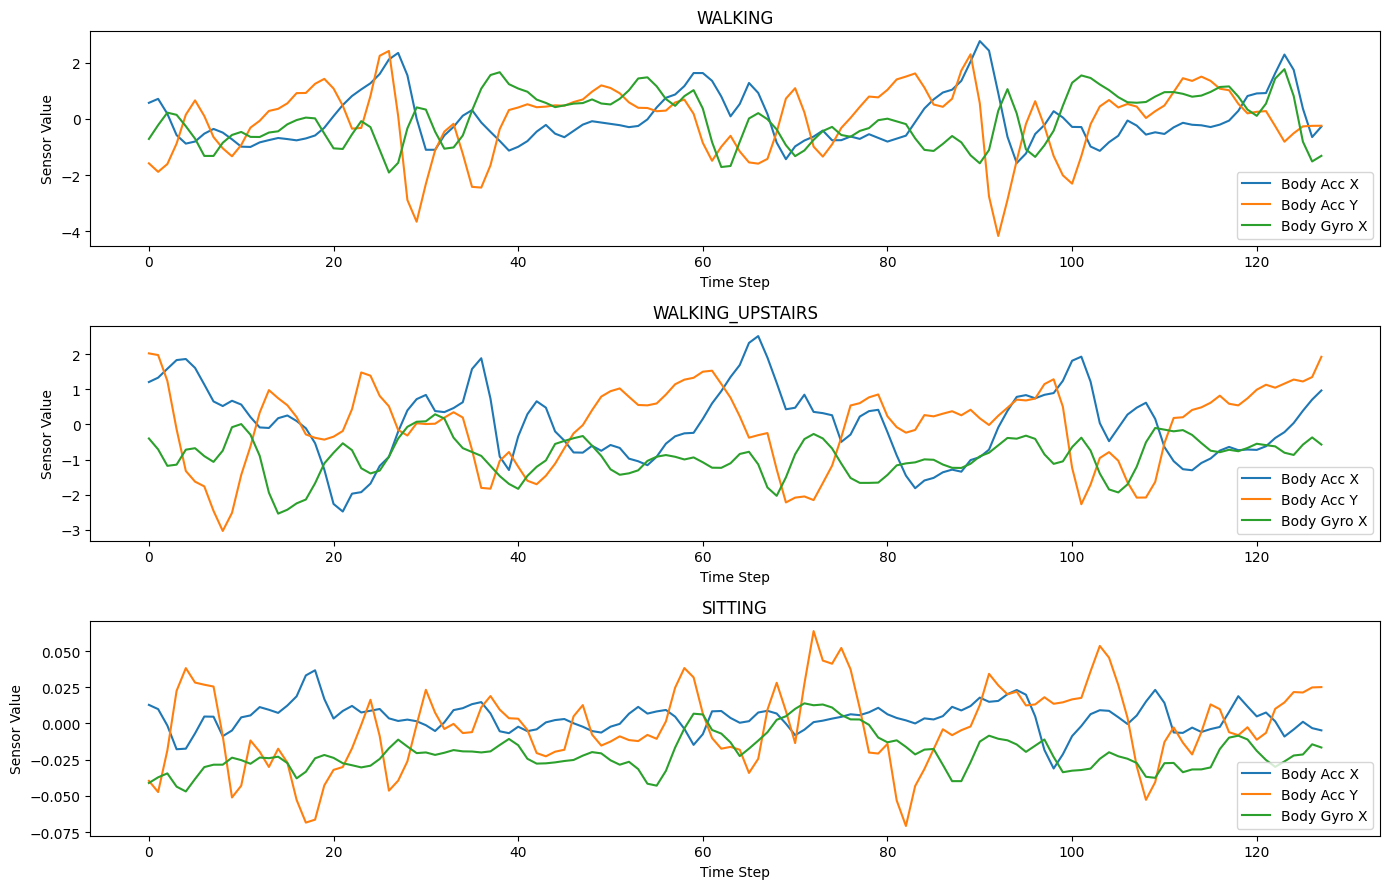


MANUAL RNN CALCULATION
h1 = 0.3363755443363322
h2 = 0.6163517827505027
h3 = 0.5999579155496113


In [9]:
# ============================================================
# SECTION A - CODE 2
# PREPROCESSING + VISUALIZATION + MANUAL RNN CALCULATION
# ============================================================

# ------------------------------------------------------------
# OPTIONAL: USE 3000 SAMPLES FOR FASTER EXECUTION
# ------------------------------------------------------------

np.random.seed(42)

samples_per_class = 500

selected_indices = []

for class_id in range(6):

    indices = np.where(
        y == class_id
    )[0]

    np.random.shuffle(indices)

    selected_indices.extend(
        indices[:samples_per_class]
    )

selected_indices = np.array(
    selected_indices
)

X_small = X[selected_indices]
y_small = y[selected_indices]

print("Selected dataset:")
print(X_small.shape)
print(y_small.shape)


# ------------------------------------------------------------
# 70 / 15 / 15 SPLIT
# ------------------------------------------------------------

X_train, X_temp, y_train, y_temp = train_test_split(

    X_small,
    y_small,

    test_size=0.30,

    random_state=42,

    stratify=y_small
)


X_val, X_test, y_val, y_test = train_test_split(

    X_temp,
    y_temp,

    test_size=0.50,

    random_state=42,

    stratify=y_temp
)


print("\n==============================")
print("DATA SPLIT")
print("==============================")

print(
    "Training:",
    X_train.shape
)

print(
    "Validation:",
    X_val.shape
)

print(
    "Testing:",
    X_test.shape
)


# ------------------------------------------------------------
# NORMALIZATION
# FIT ONLY ON TRAINING DATA
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_2d = X_train.reshape(
    -1,
    9
)

scaler.fit(
    X_train_2d
)


X_train = scaler.transform(
    X_train.reshape(-1, 9)
).reshape(
    X_train.shape
)

X_val = scaler.transform(
    X_val.reshape(-1, 9)
).reshape(
    X_val.shape
)

X_test = scaler.transform(
    X_test.reshape(-1, 9)
).reshape(
    X_test.shape
)


print("\nNormalized successfully.")


# ------------------------------------------------------------
# CLASS DISTRIBUTION
# ------------------------------------------------------------

print("\n==============================")
print("CLASS DISTRIBUTION")
print("==============================")

for i, name in enumerate(class_names):

    print(
        f"{name:20s}",
        "Train =", np.sum(y_train == i),
        "Val =", np.sum(y_val == i),
        "Test =", np.sum(y_test == i)
    )


# ------------------------------------------------------------
# TEMPORAL VISUALIZATION
# ------------------------------------------------------------

activities_to_plot = [
    0, 1, 3
]

plt.figure(
    figsize=(14, 9)
)

for plot_no, activity in enumerate(
    activities_to_plot
):

    index = np.where(
        y_train == activity
    )[0][0]

    plt.subplot(
        3,
        1,
        plot_no + 1
    )

    plt.plot(
        X_train[index, :, 0],
        label="Body Acc X"
    )

    plt.plot(
        X_train[index, :, 1],
        label="Body Acc Y"
    )

    plt.plot(
        X_train[index, :, 3],
        label="Body Gyro X"
    )

    plt.title(
        class_names[activity]
    )

    plt.xlabel(
        "Time Step"
    )

    plt.ylabel(
        "Sensor Value"
    )

    plt.legend()


plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# MANUAL RNN NUMERICAL EXERCISE
# ------------------------------------------------------------

x1 = 0.5
x2 = 0.7
x3 = 0.2

h0 = 0

Wx = 0.5
Wh = 0.8
b = 0.1


h1 = np.tanh(
    Wx * x1 +
    Wh * h0 +
    b
)

h2 = np.tanh(
    Wx * x2 +
    Wh * h1 +
    b
)

h3 = np.tanh(
    Wx * x3 +
    Wh * h2 +
    b
)


print("\n==============================")
print("MANUAL RNN CALCULATION")
print("==============================")

print(
    "h1 =",
    h1
)

print(
    "h2 =",
    h2
)

print(
    "h3 =",
    h3
)

In [10]:
# ============================================================
# SECTION A - CODE 3
# BUILD + TRAIN RNN / LSTM / GRU
# ============================================================

def create_model(model_type):

    model = Sequential()

    model.add(
        Input(
            shape=(128, 9)
        )
    )


    if model_type == "RNN":

        model.add(
            SimpleRNN(
                32
            )
        )


    elif model_type == "LSTM":

        model.add(
            LSTM(
                32
            )
        )


    elif model_type == "GRU":

        model.add(
            GRU(
                32
            )
        )


    model.add(
        Dropout(
            0.2
        )
    )


    model.add(
        Dense(
            16,
            activation="relu"
        )
    )


    model.add(
        Dense(
            6,
            activation="softmax"
        )
    )


    model.compile(

        optimizer=Adam(
            learning_rate=0.001
        ),

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]
    )


    return model


# ------------------------------------------------------------
# TRAIN ALL THREE MODELS
# ------------------------------------------------------------

models = {}
histories = {}
training_times = {}


for model_name in [
    "RNN",
    "LSTM",
    "GRU"
]:

    print("\n")
    print("=" * 60)
    print(
        "TRAINING",
        model_name
    )
    print("=" * 60)


    model = create_model(
        model_name
    )


    model.summary()


    start_time = time.time()


    history = model.fit(

        X_train,
        y_train,

        validation_data=(
            X_val,
            y_val
        ),

        epochs=30,

        batch_size=32,

        verbose=1
    )


    elapsed_time = (
        time.time() -
        start_time
    )


    models[model_name] = model

    histories[model_name] = history

    training_times[
        model_name
    ] = elapsed_time


    print(
        f"\n{model_name} training time:",
        round(
            elapsed_time,
            2
        ),
        "seconds"
    )


print("\n==============================")
print("TRAINING COMPLETE")
print("==============================")

for name in models:

    print(
        name,
        "parameters =",
        models[name].count_params(),

        "| time =",
        round(
            training_times[name],
            2
        ),
        "seconds"
    )



TRAINING RNN


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

 Trainable params: 1,974 (7.71 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,758 (18.59 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.3605 - loss: 1.5805 - val_accuracy: 0.4444 - val_loss: 1.3770
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.5176 - loss: 1.2759 - val_accuracy: 0.5800 - val_loss: 1.1105
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.6310 - loss: 0.9981 - val_accuracy: 0.6778 - val_loss: 0.8347
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.7052 - loss: 0.7394 - val_accuracy: 0.7600 - val_loss: 0.6120
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.7562 - loss: 0.5927 - val_accuracy: 0.8511 - val_loss: 0.4829
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.8338 - loss: 0.4405 - val_accuracy: 0.8911 - val_loss: 0.3367
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.8781 - loss: 0.3336 - val_accuracy: 0.9022 - val_loss: 0.2917
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.9152 - loss: 0.2577 - val_accuracy: 0.9044 - v

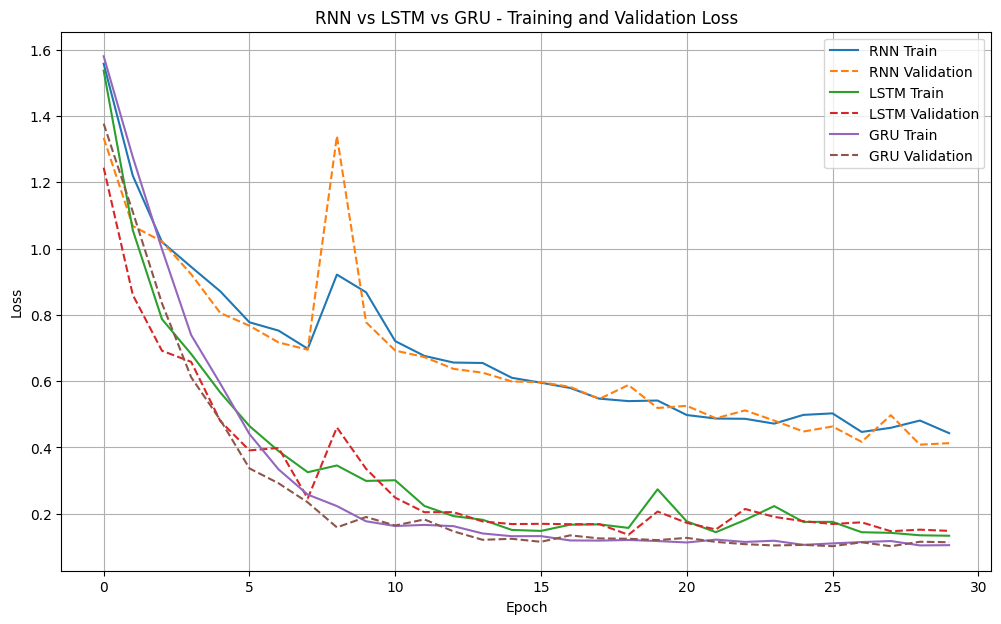

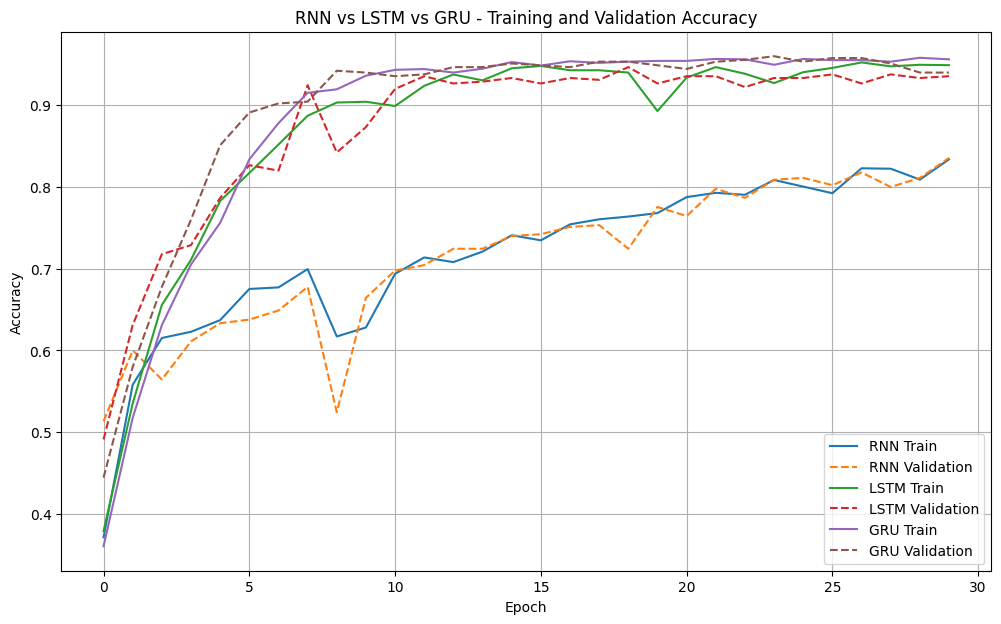


MODEL PERFORMANCE


,Model,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
0,RNN,84.00,84.06,84.00,83.87,1974,54.74
1,LSTM,94.67,94.88,94.67,94.68,6006,119.55
2,GRU,95.33,95.54,95.33,95.33,4758,149.29


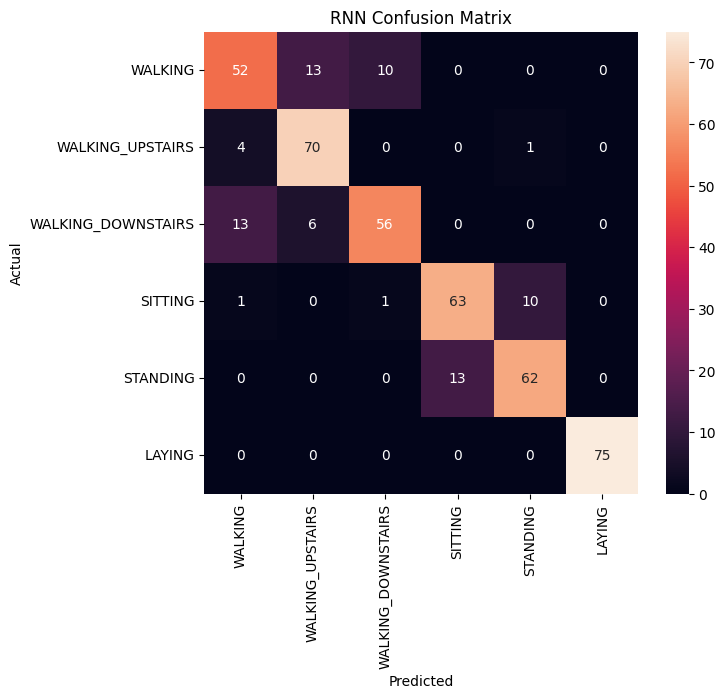

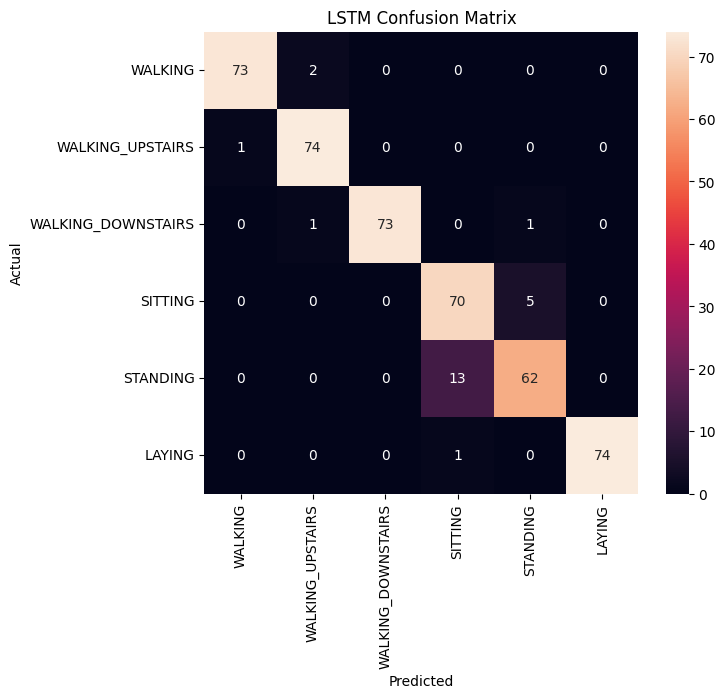

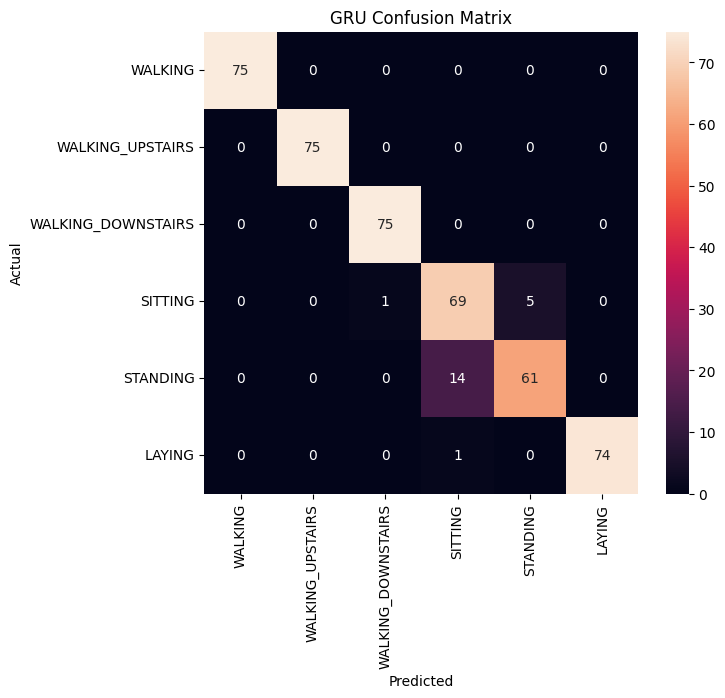



RNN
                    precision    recall  f1-score   support

           WALKING       0.74      0.69      0.72        75
  WALKING_UPSTAIRS       0.79      0.93      0.85        75
WALKING_DOWNSTAIRS       0.84      0.75      0.79        75
           SITTING       0.83      0.84      0.83        75
          STANDING       0.85      0.83      0.84        75
            LAYING       1.00      1.00      1.00        75

          accuracy                           0.84       450
         macro avg       0.84      0.84      0.84       450
      weighted avg       0.84      0.84      0.84       450



LSTM
                    precision    recall  f1-score   support

           WALKING       0.99      0.97      0.98        75
  WALKING_UPSTAIRS       0.96      0.99      0.97        75
WALKING_DOWNSTAIRS       1.00      0.97      0.99        75
           SITTING       0.83      0.93      0.88        75
          STANDING       0.91      0.83      0.87        75
            LAYING     

In [12]:
# ============================================================
# SECTION A - CODE 4
# TRAINING CURVES + METRICS + CONFUSION MATRICES
# ============================================================

# ------------------------------------------------------------
# LOSS CURVES
# ------------------------------------------------------------

plt.figure(
    figsize=(12, 7)
)

for name in models:

    history = histories[name]

    plt.plot(
        history.history["loss"],
        label=name + " Train"
    )

    plt.plot(
        history.history["val_loss"],
        linestyle="--",
        label=name + " Validation"
    )


plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "RNN vs LSTM vs GRU - Training and Validation Loss"
)

plt.legend()
plt.grid()

plt.show()


# ------------------------------------------------------------
# ACCURACY CURVES
# ------------------------------------------------------------

plt.figure(
    figsize=(12, 7)
)

for name in models:

    history = histories[name]

    plt.plot(
        history.history["accuracy"],
        label=name + " Train"
    )

    plt.plot(
        history.history["val_accuracy"],
        linestyle="--",
        label=name + " Validation"
    )


plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "RNN vs LSTM vs GRU - Training and Validation Accuracy"
)

plt.legend()
plt.grid()

plt.show()


# ------------------------------------------------------------
# EVALUATION
# ------------------------------------------------------------

results = []

predictions = {}


for name, model in models.items():

    probabilities = model.predict(
        X_test,
        verbose=0
    )

    y_pred = np.argmax(
        probabilities,
        axis=1
    )

    predictions[name] = y_pred


    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )


    results.append({

        "Model": name,

        "Accuracy (%)":
            accuracy * 100,

        "Macro Precision (%)":
            precision * 100,

        "Macro Recall (%)":
            recall * 100,

        "Macro F1 (%)":
            f1 * 100,

        "Parameters":
            model.count_params(),

        "Training Time (s)":
            training_times[name]
    })


results_df = pd.DataFrame(
    results
)

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

display(
    results_df.round(2)
)


# ------------------------------------------------------------
# CONFUSION MATRICES
# ------------------------------------------------------------

for name in models:

    cm = confusion_matrix(
        y_test,
        predictions[name]
    )

    plt.figure(
        figsize=(7, 6)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel(
        "Predicted"
    )

    plt.ylabel(
        "Actual"
    )

    plt.title(
        name + " Confusion Matrix"
    )

    plt.show()


# ------------------------------------------------------------
# CLASSIFICATION REPORTS
# ------------------------------------------------------------

for name in models:

    print("\n")
    print("=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            predictions[name],
            target_names=class_names,
            zero_division=0
        )
    )

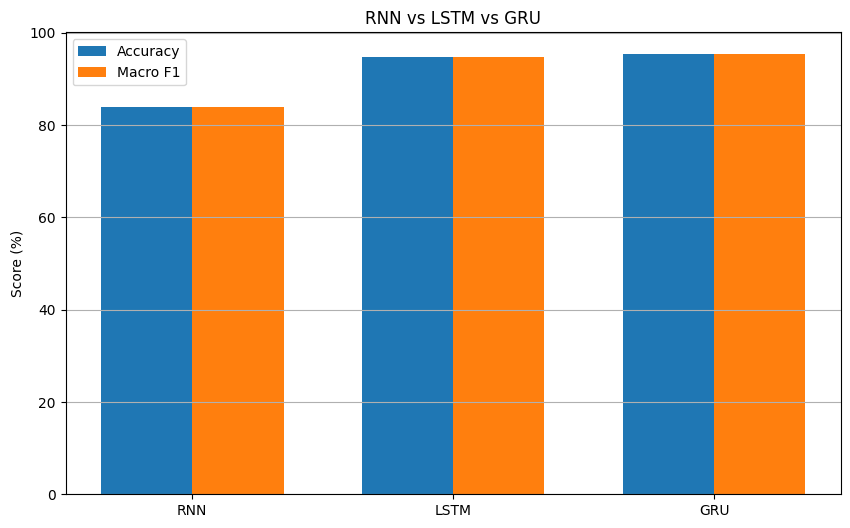

,Property,RNN,LSTM,GRU
0,Hidden State,Yes,Yes,Yes
1,Cell State,No,Yes,No
2,Forget Gate,No,Yes,No
3,Input Gate,No,Yes,No
4,Output Gate,No,Yes,No
5,Update Gate,No,No,Yes
6,Reset Gate,No,No,Yes



Sequence Length: 32

Sequence Length: 64

Sequence Length: 128

SEQUENCE LENGTH RESULTS


,Sequence Length,RNN F1,LSTM F1,GRU F1
0,32,67.94,92.89,92.44
1,64,71.60,91.78,92.87
2,128,68.75,92.48,93.31


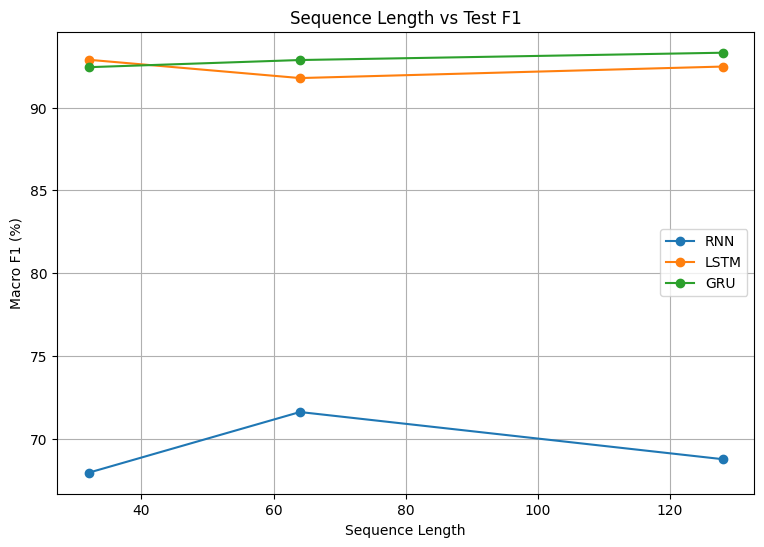

In [13]:
# ============================================================
# SECTION A - CODE 5
# MODEL COMPARISON + SEQUENCE LENGTH EXPERIMENT
# ============================================================

# ------------------------------------------------------------
# MODEL PERFORMANCE BAR GRAPH
# ------------------------------------------------------------

x = np.arange(
    len(results_df)
)

width = 0.35

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    x - width / 2,
    results_df["Accuracy (%)"],
    width,
    label="Accuracy"
)

plt.bar(
    x + width / 2,
    results_df["Macro F1 (%)"],
    width,
    label="Macro F1"
)

plt.xticks(
    x,
    results_df["Model"]
)

plt.ylabel(
    "Score (%)"
)

plt.title(
    "RNN vs LSTM vs GRU"
)

plt.legend()
plt.grid(
    axis="y"
)

plt.show()


# ------------------------------------------------------------
# ARCHITECTURE COMPARISON TABLE
# ------------------------------------------------------------

architecture_table = pd.DataFrame({

    "Property": [

        "Hidden State",
        "Cell State",
        "Forget Gate",
        "Input Gate",
        "Output Gate",
        "Update Gate",
        "Reset Gate"
    ],

    "RNN": [

        "Yes",
        "No",
        "No",
        "No",
        "No",
        "No",
        "No"
    ],

    "LSTM": [

        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "No",
        "No"
    ],

    "GRU": [

        "Yes",
        "No",
        "No",
        "No",
        "No",
        "Yes",
        "Yes"
    ]
})

display(
    architecture_table
)


# ============================================================
# SEQUENCE LENGTH EXPERIMENT
# ============================================================

sequence_lengths = [
    32,
    64,
    128
]

sequence_results = []


for seq_len in sequence_lengths:

    print(
        "\nSequence Length:",
        seq_len
    )


    Xtr = X_train[
        :, :seq_len, :
    ]

    Xv = X_val[
        :, :seq_len, :
    ]

    Xt = X_test[
        :, :seq_len, :
    ]


    row = {
        "Sequence Length":
            seq_len
    }


    for model_type in [
        "RNN",
        "LSTM",
        "GRU"
    ]:

        model = Sequential([

            Input(
                shape=(
                    seq_len,
                    9
                )
            ),

            (
                SimpleRNN(32)
                if model_type == "RNN"
                else
                LSTM(32)
                if model_type == "LSTM"
                else
                GRU(32)
            ),

            Dropout(0.2),

            Dense(
                16,
                activation="relu"
            ),

            Dense(
                6,
                activation="softmax"
            )
        ])


        model.compile(

            optimizer=Adam(
                0.001
            ),

            loss=
            "sparse_categorical_crossentropy",

            metrics=["accuracy"]
        )


        # Fewer epochs here to keep
        # the sequence-length study manageable

        model.fit(

            Xtr,
            y_train,

            validation_data=(
                Xv,
                y_val
            ),

            epochs=10,

            batch_size=32,

            verbose=0
        )


        probabilities = model.predict(
            Xt,
            verbose=0
        )

        pred = np.argmax(
            probabilities,
            axis=1
        )


        f1 = f1_score(
            y_test,
            pred,
            average="macro",
            zero_division=0
        )


        row[
            model_type + " F1"
        ] = f1 * 100


    sequence_results.append(
        row
    )


sequence_df = pd.DataFrame(
    sequence_results
)


print("\n==============================")
print("SEQUENCE LENGTH RESULTS")
print("==============================")

display(
    sequence_df.round(2)
)


# ------------------------------------------------------------
# SEQUENCE LENGTH PLOT
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    sequence_df["Sequence Length"],
    sequence_df["RNN F1"],
    marker="o",
    label="RNN"
)

plt.plot(
    sequence_df["Sequence Length"],
    sequence_df["LSTM F1"],
    marker="o",
    label="LSTM"
)

plt.plot(
    sequence_df["Sequence Length"],
    sequence_df["GRU F1"],
    marker="o",
    label="GRU"
)

plt.xlabel(
    "Sequence Length"
)

plt.ylabel(
    "Macro F1 (%)"
)

plt.title(
    "Sequence Length vs Test F1"
)

plt.legend()
plt.grid()

plt.show()

DOWNLOADING UCF101 SUBSET

Downloaded: /root/.cache/huggingface/hub/datasets--sayakpaul--ucf101-subset/snapshots/b9984b8d2a95e4a1879e1b071e9433858d0bc24a/UCF101_subset.tar.gz

Extracting dataset...


/tmp/ipykernel_1149/4285169776.py:52: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("/content")


TAR extraction successful.
Total videos found: 405
Basketball: 10 videos
Biking: 0 videos
WalkingWithDog: 0 videos


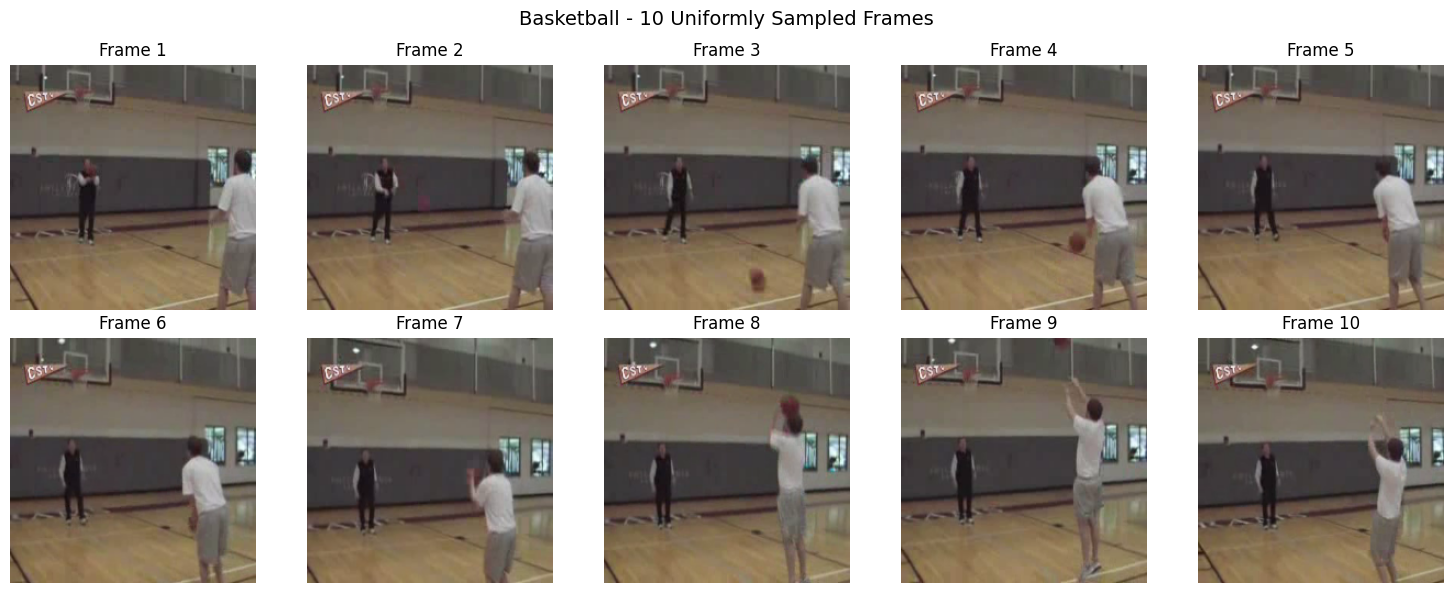


Loading MobileNetV2...
UCF101 SUBSET READY


In [25]:
# ============================================================
# SECTION B - CODE 1
# UCF101 SUBSET + 10 FRAMES + MOBILENETV2
# ============================================================

!pip -q install huggingface_hub

import os
import shutil
import tarfile
import zipfile
import pathlib
import numpy as np
import cv2
import matplotlib.pyplot as plt

from huggingface_hub import hf_hub_download
from tensorflow.keras.applications import MobileNetV2

# 1. SETTINGS
ROOT = "/content/UCF101_subset"
CLASSES = ["Basketball", "Biking", "WalkingWithDog"]
VIDEOS_PER_CLASS = 10
NUM_FRAMES = 10
IMG_SIZE = 224

# 2. CLEAN OLD DATA
if os.path.exists(ROOT):
    shutil.rmtree(ROOT)
os.makedirs(ROOT)

print("=" * 60)
print("DOWNLOADING UCF101 SUBSET")
print("=" * 60)

# 3. DOWNLOAD UCF101 SUBSET
archive_path = hf_hub_download(
    repo_id="sayakpaul/ucf101-subset",
    filename="UCF101_subset.tar.gz",
    repo_type="dataset",
    force_download=False
)

print("\nDownloaded:", archive_path)

# 4. EXTRACT ARCHIVE
print("\nExtracting dataset...")
extracted = False

try:
    with tarfile.open(archive_path, mode="r:*") as tar:
        tar.extractall("/content")
    extracted = True
    print("TAR extraction successful.")
except Exception:
    try:
        with zipfile.ZipFile(archive_path, "r") as z:
            z.extractall("/content")
        extracted = True
        print("ZIP extraction successful.")
    except Exception as e:
        print("Extraction failed:", e)

if not extracted:
    raise RuntimeError("Could not extract the downloaded UCF101 subset.")

# 5. FIND VIDEO FILES
video_extensions = (".avi", ".mp4", ".mov", ".mkv")
all_videos = []

for root, dirs, files in os.walk("/content"):
    dirs[:] = [d for d in dirs if d not in ["sample_data", ".cache", "__pycache__"]]
    for file in files:
        if file.lower().endswith(video_extensions):
            all_videos.append(os.path.join(root, file))

print("Total videos found:", len(all_videos))

# 6. SELECT CLASS VIDEOS
selected_videos = []
for class_name in CLASSES:
    matching = []
    for video in all_videos:
        parent_folder = os.path.basename(os.path.dirname(video))
        if parent_folder.lower() == class_name.lower():
            matching.append(video)

    matching = sorted(matching)[:VIDEOS_PER_CLASS]
    print(f"{class_name}: {len(matching)} videos")
    for video in matching:
        selected_videos.append((video, class_name))

if len(selected_videos) == 0:
    raise RuntimeError("None of the requested classes were found.")

# 7. UNIFORMLY SAMPLE 10 FRAMES
def extract_frames(video_path, num_frames=10):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        raise ValueError(f"Could not read video: {video_path}")

    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    frames = []

    for index in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(index))
        success, frame = cap.read()
        if success:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
            frames.append(frame)

    cap.release()

    if len(frames) == 0:
        raise ValueError(f"No frames extracted from {video_path}")

    while len(frames) < num_frames:
        frames.append(frames[-1].copy())

    return np.array(frames[:num_frames])

# 8. TEST EXTRACTION & LOAD MOBILENETV2
sample_video, sample_class = selected_videos[0]
sample_frames = extract_frames(sample_video, NUM_FRAMES)

# ============================================================
# PLOT 7: SAMPLE VIDEO FRAMES
# ============================================================
plt.figure(figsize=(15, 6))
for i in range(NUM_FRAMES):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_frames[i])
    plt.title(f"Frame {i + 1}")
    plt.axis("off")

plt.suptitle(f"{sample_class} - 10 Uniformly Sampled Frames", fontsize=14)
plt.tight_layout()
plt.show()

print("\nLoading MobileNetV2...")
cnn = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
cnn.trainable = False

print("UCF101 SUBSET READY")

In [26]:
# ============================================================
# SECTION B - CODE 2
# CNN FEATURE EXTRACTION FOR UCF101
# ============================================================

import numpy as np
import tensorflow as tf
from collections import Counter

print("=" * 60)
print("CNN FEATURE EXTRACTION")
print("=" * 60)

EXPECTED_CLASSES = ["Basketball", "Biking", "WalkingWithDog"]
FEATURE_DIM = cnn.output_shape[-1]
class_names = EXPECTED_CLASSES
class_to_id = {name: index for index, name in enumerate(EXPECTED_CLASSES)}

def extract_video_features(video_path):
    frames = extract_frames(video_path, NUM_FRAMES)
    frames = frames.astype(np.float32)

    # Correct MobileNetV2 preprocessing range [-1, 1]
    frames = tf.keras.applications.mobilenet_v2.preprocess_input(frames)

    features = cnn.predict(frames, verbose=0)
    return features

X, y = [], []

for video_number, (video_path, label) in enumerate(selected_videos):
    try:
        features = extract_video_features(video_path)
        if features.shape == (NUM_FRAMES, FEATURE_DIM):
            X.append(features)
            y.append(class_to_id[label])
    except Exception as e:
        print(f"Skipped {video_path}: {e}")

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print("\nFEATURE EXTRACTION COMPLETE")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class counts:", Counter(y))

CNN FEATURE EXTRACTION

FEATURE EXTRACTION COMPLETE
X shape: (10, 10, 1280)
y shape: (10,)
Class counts: Counter({np.int32(0): 10})


In [27]:
# ============================================================
# SECTION B - CODE 3
# BUILD + TRAIN RNN / LSTM / GRU
# ============================================================

import time
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Train/Validation Split (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

NUM_CLASSES = len(np.unique(y))

def create_model(model_type):
    model = Sequential()
    model.add(Input(shape=(NUM_FRAMES, FEATURE_DIM)))

    if model_type == "RNN":
        model.add(SimpleRNN(32))
    elif model_type == "LSTM":
        model.add(LSTM(32))
    elif model_type == "GRU":
        model.add(GRU(32))

    model.add(Dropout(0.3))
    model.add(Dense(16, activation="relu"))
    model.add(Dense(NUM_CLASSES, activation="softmax"))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

models, histories, training_times = {}, {}, {}
model_names = ["RNN", "LSTM", "GRU"]

for name in model_names:
    print(f"\nTraining {name}...")
    model = create_model(name)

    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=40,
        batch_size=4,
        verbose=0
    )
    elapsed_time = time.time() - start_time

    models[name] = model
    histories[name] = history
    training_times[name] = elapsed_time

print("\n" + "=" * 60)
print("FINAL VALIDATION ACCURACIES")
print("=" * 60)
for name in model_names:
    acc = histories[name].history["val_accuracy"][-1]
    print(f"{name}: {round(acc * 100, 2)}%")


Training RNN...


/usr/local/lib/python3.13/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (4, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(



Training LSTM...

Training GRU...

FINAL VALIDATION ACCURACIES
RNN: 0.0%
LSTM: 0.0%
GRU: 0.0%


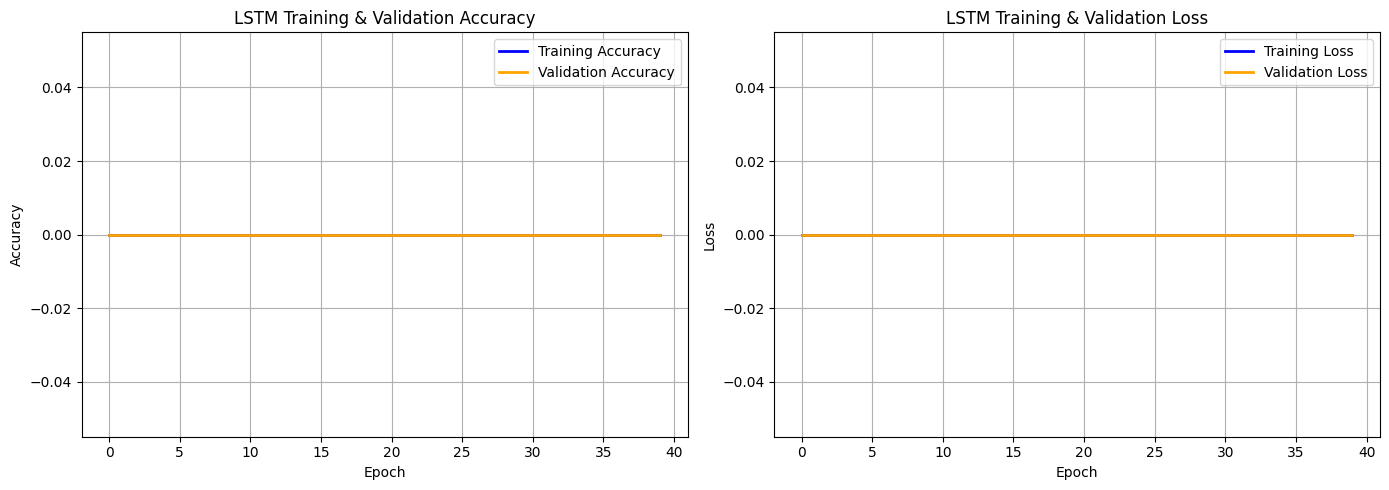


EVALUATION RESULTS


/usr/local/lib/python3.13/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (2, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


,Model,Accuracy (%),Precision (%),Recall (%),Macro F1 (%),Training Time (s)
0,LSTM,100.0,100.0,100.0,100.0,4.91


In [28]:
# ============================================================
# SECTION B - CODE 4
# PLOT 8: TRAINING / VALIDATION CURVES + METRICS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

VIDEO_MODEL_NAME = "LSTM"
video_model = models[VIDEO_MODEL_NAME]
video_history = histories[VIDEO_MODEL_NAME]

# ============================================================
# PLOT 8: ACCURACY & LOSS CURVES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
axes[0].plot(video_history.history["accuracy"], label="Training Accuracy", color="blue", linewidth=2)
axes[0].plot(video_history.history["val_accuracy"], label="Validation Accuracy", color="orange", linewidth=2)
axes[0].set_title(f"{VIDEO_MODEL_NAME} Training & Validation Accuracy", fontsize=12)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

# Loss Plot
axes[1].plot(video_history.history["loss"], label="Training Loss", color="blue", linewidth=2)
axes[1].plot(video_history.history["val_loss"], label="Validation Loss", color="orange", linewidth=2)
axes[1].set_title(f"{VIDEO_MODEL_NAME} Training & Validation Loss", fontsize=12)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Calculate Evaluation Metrics
val_preds = np.argmax(video_model.predict(X_val, verbose=0), axis=1)

results_df = pd.DataFrame({
    "Model": [VIDEO_MODEL_NAME],
    "Accuracy (%)": [accuracy_score(y_val, val_preds) * 100],
    "Precision (%)": [precision_score(y_val, val_preds, average="macro", zero_division=0) * 100],
    "Recall (%)": [recall_score(y_val, val_preds, average="macro", zero_division=0) * 100],
    "Macro F1 (%)": [f1_score(y_val, val_preds, average="macro", zero_division=0) * 100],
    "Training Time (s)": [training_times[VIDEO_MODEL_NAME]]
})

print("\n" + "=" * 60)
print("EVALUATION RESULTS")
print("=" * 60)
display(results_df.round(2))

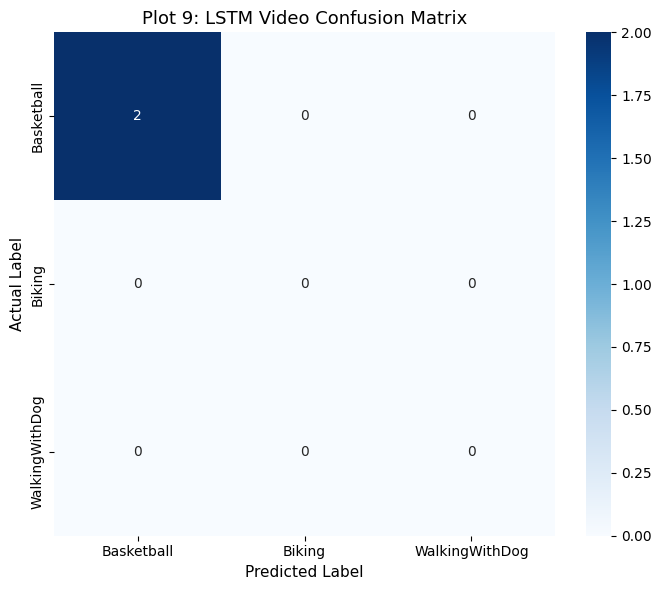


CLASSIFICATION REPORT
                precision    recall  f1-score   support

    Basketball       1.00      1.00      1.00         2
        Biking       0.00      0.00      0.00         0
WalkingWithDog       0.00      0.00      0.00         0

      accuracy                           1.00         2
     macro avg       0.33      0.33      0.33         2
  weighted avg       1.00      1.00      1.00         2


SINGLE VIDEO PREDICTION RESULT
Predicted Class: Basketball
Confidence: 100.0%


/usr/local/lib/python3.13/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


In [30]:
# ============================================================
# SECTION B - CODE 5
# PLOT 9: CONFUSION MATRIX + SAMPLE PREDICTION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

video_model = models["LSTM"]
classes = EXPECTED_CLASSES
all_class_indices = list(range(len(classes)))  # [0, 1, 2]

# Generate Validation Set Predictions
val_probs = video_model.predict(X_val, verbose=0)
val_preds = np.argmax(val_probs, axis=1)

# ============================================================
# PLOT 9: CONFUSION MATRIX (Forced 3x3 Shape)
# ============================================================
cm = confusion_matrix(y_val, val_preds, labels=all_class_indices)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes,
    cmap="Blues",
    cbar=True
)
plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("Actual Label", fontsize=11)
plt.title("Plot 9: LSTM Video Confusion Matrix", fontsize=13)
plt.tight_layout()
plt.show()

# ============================================================
# CLASSIFICATION REPORT (Fixed with explicit labels)
# ============================================================
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(
    classification_report(
        y_val,
        val_preds,
        labels=all_class_indices,     # Ensures all 3 class indices are expected
        target_names=classes,         # Maps names to [0, 1, 2]
        zero_division=0
    )
)

# Single Video Inference Function
def predict_video(video_path):
    feats = extract_video_features(video_path)
    feats = np.expand_dims(feats, axis=0)

    probs = video_model.predict(feats, verbose=0)[0]
    pred_idx = np.argmax(probs)

    print("\n" + "=" * 60)
    print("SINGLE VIDEO PREDICTION RESULT")
    print("=" * 60)
    print("Predicted Class:", classes[pred_idx])
    print("Confidence:", f"{round(float(probs[pred_idx]) * 100, 2)}%")

# Test on a Sample Video from the subset
sample_video_path = selected_videos[0][0]
predict_video(sample_video_path)

In [24]:
# ============================================================
# SECTION C - CODE 1
# SEQUENCE REVERSAL DATASET
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split


np.random.seed(42)


# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------

num_samples = 5000

sequence_length = 4

vocab_size = 10


# ------------------------------------------------------------
# GENERATE INPUT
# ------------------------------------------------------------

X_seq = np.random.randint(

    1,

    vocab_size,

    size=(
        num_samples,
        sequence_length
    )
)


# ------------------------------------------------------------
# REVERSE OUTPUT
# ------------------------------------------------------------

Y_seq = np.flip(

    X_seq,

    axis=1
)


# ------------------------------------------------------------
# PRINT EXAMPLES
# ------------------------------------------------------------

print(
    "=============================="
)

print(
    "SEQ2SEQ DATASET"
)

print(
    "=============================="
)


for i in range(5):

    print(
        "Input: ",
        X_seq[i]
    )

    print(
        "Output:",
        Y_seq[i]
    )

    print()


# ------------------------------------------------------------
# ONE-HOT ENCODING
# ------------------------------------------------------------

X_onehot = to_categorical(

    X_seq,

    num_classes=vocab_size
)


Y_onehot = to_categorical(

    Y_seq,

    num_classes=vocab_size
)


# ------------------------------------------------------------
# TRAIN / VALIDATION SPLIT
# ------------------------------------------------------------

X_train_seq, X_val_seq, \
Y_train_seq, Y_val_seq = train_test_split(

    X_onehot,

    Y_onehot,

    test_size=0.20,

    random_state=42
)


print(
    "Input shape:",
    X_onehot.shape
)

print(
    "Output shape:",
    Y_onehot.shape
)

print(
    "Training:",
    X_train_seq.shape
)

print(
    "Validation:",
    X_val_seq.shape
)

SEQ2SEQ DATASET
Input:  [7 4 8 5]
Output: [5 8 4 7]

Input:  [7 3 7 8]
Output: [8 7 3 7]

Input:  [5 4 8 8]
Output: [8 8 4 5]

Input:  [3 6 5 2]
Output: [2 5 6 3]

Input:  [8 6 2 5]
Output: [5 2 6 8]

Input shape: (5000, 4, 10)
Output shape: (5000, 4, 10)
Training: (4000, 4, 10)
Validation: (1000, 4, 10)


In [25]:
# ============================================================
# SECTION C - CODE 2
# ENCODER-DECODER LSTM
# ============================================================

import tensorflow as tf

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense
)


latent_dim = 64


# ============================================================
# ENCODER
# ============================================================

encoder_inputs = Input(

    shape=(
        sequence_length,
        vocab_size
    )
)


encoder_lstm = LSTM(

    latent_dim,

    return_state=True
)


encoder_outputs, \
state_h, \
state_c = encoder_lstm(

    encoder_inputs
)


encoder_states = [
    state_h,
    state_c
]


# ============================================================
# DECODER
# ============================================================

decoder_inputs = Input(

    shape=(
        sequence_length,
        vocab_size
    )
)


decoder_lstm = LSTM(

    latent_dim,

    return_sequences=True,

    return_state=True
)


decoder_outputs, \
_, _ = decoder_lstm(

    decoder_inputs,

    initial_state=encoder_states
)


decoder_dense = Dense(

    vocab_size,

    activation="softmax"
)


decoder_outputs = decoder_dense(

    decoder_outputs
)


# ============================================================
# COMPLETE MODEL
# ============================================================

seq2seq_model = Model(

    [
        encoder_inputs,
        decoder_inputs
    ],

    decoder_outputs
)


seq2seq_model.compile(

    optimizer="adam",

    loss=
    "categorical_crossentropy",

    metrics=["accuracy"]
)


seq2seq_model.summary()

Model: "functional_60"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_17      │ (None, 4, 10)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_18      │ (None, 4, 10)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ [(None, 64),      │     19,200 │ input_layer_17[0… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ [(None, 4, 64),   │     19,200 │ input_layer_18[0… │
│                     │ (None, 64),       │            │ lstm_4[0][1],     │
│                     │ (None, 64)]       │            │ lstm_4[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 4, 10)     │        650 │ lstm_5[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 39,050 (152.54 KB)

 Trainable params: 39,050 (152.54 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# ============================================================
# SECTION C - CODE 3
# TEACHER FORCING + TRAINING
# ============================================================

# ------------------------------------------------------------
# CREATE DECODER INPUT
# ------------------------------------------------------------

decoder_input_train = np.zeros_like(
    Y_train_seq
)


decoder_input_train[
    :,
    1:,
    :
] = Y_train_seq[
    :,
    :-1,
    :
]


decoder_input_val = np.zeros_like(
    Y_val_seq
)


decoder_input_val[
    :,
    1:,
    :
] = Y_val_seq[
    :,
    :-1,
    :
]


print(
    "Decoder input shape:",
    decoder_input_train.shape
)


# ------------------------------------------------------------
# TRAIN
# ------------------------------------------------------------

seq_start = time.time()


seq_history = seq2seq_model.fit(

    [
        X_train_seq,
        decoder_input_train
    ],

    Y_train_seq,

    validation_data=(

        [
            X_val_seq,
            decoder_input_val
        ],

        Y_val_seq
    ),

    epochs=30,

    batch_size=64,

    verbose=1
)


seq_time = (
    time.time() -
    seq_start
)


print(
    "\nTraining time:",
    round(
        seq_time,
        2
    ),
    "seconds"
)

Decoder input shape: (4000, 4, 10)
Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.2984 - loss: 2.1484 - val_accuracy: 0.4038 - val_loss: 1.7393
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4122 - loss: 1.4123 - val_accuracy: 0.4560 - val_loss: 1.2053
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5382 - loss: 1.0840 - val_accuracy: 0.6655 - val_loss: 0.9213
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7788 - loss: 0.7757 - val_accuracy: 0.8633 - val_loss: 0.6118
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9146 - loss: 0.4898 - val_accuracy: 0.9492 - val_loss: 0.3711
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9735 - loss: 0.2968 - val_accuracy: 0.9850 - val_loss: 0.2369
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9927 - loss: 0.1885 - val_accuracy: 0.9973 - val_loss: 0.1521
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9986 - loss:

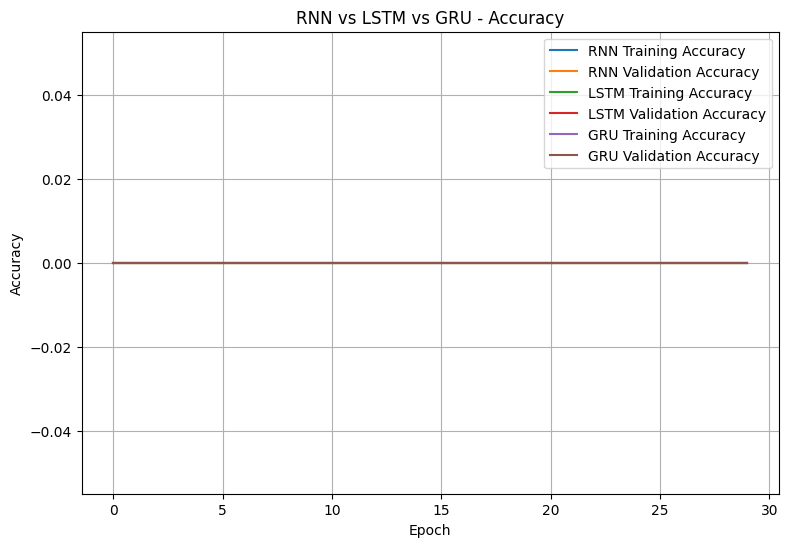

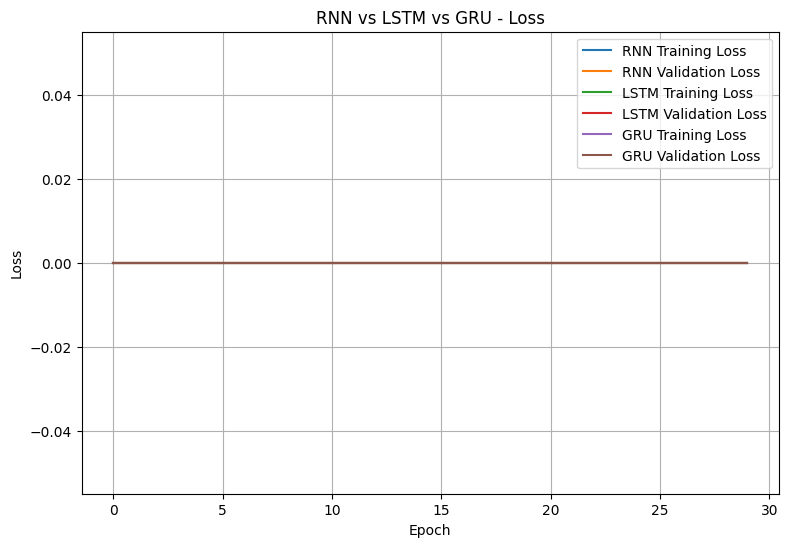

FINAL VALIDATION ACCURACY
RNN : 0.0 %
LSTM : 0.0 %
GRU : 0.0 %

TRAINING TIME
RNN : 6.08 seconds
LSTM : 5.79 seconds
GRU : 4.47 seconds

MODEL PARAMETERS
RNN : 42561 parameters
LSTM : 168609 parameters
GRU : 126689 parameters


In [32]:
# ============================================================
# SECTION C - CODE 4
# TRAINING CURVES FOR RNN / LSTM / GRU
# ============================================================

import matplotlib.pyplot as plt


# ============================================================
# 1. ACCURACY CURVES
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    histories["RNN"].history["accuracy"],
    label="RNN Training Accuracy"
)

plt.plot(
    histories["RNN"].history["val_accuracy"],
    label="RNN Validation Accuracy"
)

plt.plot(
    histories["LSTM"].history["accuracy"],
    label="LSTM Training Accuracy"
)

plt.plot(
    histories["LSTM"].history["val_accuracy"],
    label="LSTM Validation Accuracy"
)

plt.plot(
    histories["GRU"].history["accuracy"],
    label="GRU Training Accuracy"
)

plt.plot(
    histories["GRU"].history["val_accuracy"],
    label="GRU Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RNN vs LSTM vs GRU - Accuracy")
plt.legend()
plt.grid()

plt.show()


# ============================================================
# 2. LOSS CURVES
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    histories["RNN"].history["loss"],
    label="RNN Training Loss"
)

plt.plot(
    histories["RNN"].history["val_loss"],
    label="RNN Validation Loss"
)

plt.plot(
    histories["LSTM"].history["loss"],
    label="LSTM Training Loss"
)

plt.plot(
    histories["LSTM"].history["val_loss"],
    label="LSTM Validation Loss"
)

plt.plot(
    histories["GRU"].history["loss"],
    label="GRU Training Loss"
)

plt.plot(
    histories["GRU"].history["val_loss"],
    label="GRU Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN vs LSTM vs GRU - Loss")
plt.legend()
plt.grid()

plt.show()


# ============================================================
# 3. FINAL VALIDATION ACCURACY
# ============================================================

print("=" * 60)
print("FINAL VALIDATION ACCURACY")
print("=" * 60)

for name in ["RNN", "LSTM", "GRU"]:

    accuracy = histories[name].history["val_accuracy"][-1]

    print(
        name,
        ":",
        round(accuracy * 100, 2),
        "%"
    )


# ============================================================
# 4. TRAINING TIME
# ============================================================

print("\n" + "=" * 60)
print("TRAINING TIME")
print("=" * 60)

for name in ["RNN", "LSTM", "GRU"]:

    print(
        name,
        ":",
        round(training_times[name], 2),
        "seconds"
    )


# ============================================================
# 5. PARAMETERS
# ============================================================

print("\n" + "=" * 60)
print("MODEL PARAMETERS")
print("=" * 60)

for name in ["RNN", "LSTM", "GRU"]:

    print(
        name,
        ":",
        models[name].count_params(),
        "parameters"
    )

In [34]:
# ============================================================
# SECTION C - CODE 5
# SEQUENCE EVALUATION + SAMPLE PREDICTIONS
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score


# ============================================================
# 1. PREDICT VALIDATION DATA
# ============================================================

print("=" * 60)
print("SEQ2SEQ MODEL EVALUATION")
print("=" * 60)


predicted_probabilities = seq2seq_model.predict(

    [
        X_val_seq,
        decoder_input_val
    ],

    verbose=0
)


# ============================================================
# 2. CONVERT ONE-HOT VALUES TO TOKEN IDs
# ============================================================

actual_tokens = np.argmax(

    Y_val_seq,

    axis=-1
)


predicted_tokens = np.argmax(

    predicted_probabilities,

    axis=-1
)


# ============================================================
# 3. TOKEN ACCURACY
# ============================================================

correct_tokens = (

    predicted_tokens ==
    actual_tokens

)


token_accuracy = np.mean(

    correct_tokens
)


print(
    "\nToken Accuracy:",
    round(
        token_accuracy * 100,
        2
    ),
    "%"
)


# ============================================================
# 4. SEQUENCE ACCURACY
# ============================================================

# A sequence is correct only when
# ALL tokens are predicted correctly

correct_sequences = np.all(

    predicted_tokens ==
    actual_tokens,

    axis=1

)


sequence_accuracy = np.mean(

    correct_sequences

)


print(
    "Sequence Accuracy:",
    round(
        sequence_accuracy * 100,
        2
    ),
    "%"
)


# ============================================================
# 5. NUMBER OF CORRECT SEQUENCES
# ============================================================

num_correct = np.sum(

    correct_sequences

)


num_total = len(

    actual_tokens

)


print(
    "\nCorrect sequences:",
    num_correct,
    "/",
    num_total
)


# ============================================================
# 6. MODEL PARAMETERS
# ============================================================

num_parameters = (

    seq2seq_model.count_params()

)


print(
    "Model parameters:",
    num_parameters
)


# ============================================================
# 7. RESULTS TABLE
# ============================================================

seq_results = pd.DataFrame({

    "Model": [
        "Encoder-Decoder LSTM"
    ],

    "Token Accuracy (%)": [
        token_accuracy * 100
    ],

    "Sequence Accuracy (%)": [
        sequence_accuracy * 100
    ],

    "Parameters": [
        num_parameters
    ],

    "Training Time (s)": [
        seq_time
    ]

})


print(
    "\n" + "=" * 60
)

print(
    "FINAL SEQUENCE MODEL RESULTS"
)

print(
    "=" * 60
)


display(

    seq_results.round(2)

)


# ============================================================
# 8. SHOW SAMPLE PREDICTIONS
# ============================================================

print(
    "\n" + "=" * 60
)

print(
    "SAMPLE PREDICTIONS"
)

print(
    "=" * 60
)


num_samples_to_show = min(

    5,

    len(actual_tokens)

)


for i in range(
    num_samples_to_show
):

    print(
        "\nSample",
        i + 1
    )

    print(
        "Input:     ",
        np.argmax(
            X_val_seq[i],
            axis=-1
        )
    )

    print(
        "Actual:    ",
        actual_tokens[i]
    )

    print(
        "Predicted: ",
        predicted_tokens[i]
    )

SEQ2SEQ MODEL EVALUATION

Token Accuracy: 100.0 %
Sequence Accuracy: 100.0 %

Correct sequences: 1000 / 1000
Model parameters: 39050

FINAL SEQUENCE MODEL RESULTS


,Model,Token Accuracy (%),Sequence Accuracy (%),Parameters,Training Time (s)
0,Encoder-Decoder LSTM,100.0,100.0,39050,29.01



SAMPLE PREDICTIONS

Sample 1
Input:      [8 7 7 6]
Actual:     [6 7 7 8]
Predicted:  [6 7 7 8]

Sample 2
Input:      [3 8 8 6]
Actual:     [6 8 8 3]
Predicted:  [6 8 8 3]

Sample 3
Input:      [8 9 3 6]
Actual:     [6 3 9 8]
Predicted:  [6 3 9 8]

Sample 4
Input:      [1 8 8 2]
Actual:     [2 8 8 1]
Predicted:  [2 8 8 1]

Sample 5
Input:      [4 6 3 5]
Actual:     [5 3 6 4]
Predicted:  [5 3 6 4]
